In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

print("PyBaMM version:", pybamm.__version__)
print("NumPy version:", np.__version__)

PyBaMM version: 26.3.1
NumPy version: 2.4.4


In [2]:
# 1. 选菜谱：SPMe (Single Particle Model with electrolyte)
model = pybamm.lithium_ion.SPMe()

# 2. 选食材：Chen2020 (LG M50 baseline, 化学体系近似 LG INR18650 MJ1)
parameter_values = pybamm.ParameterValues("Chen2020")

# 3. 看看这个参数集的电池标称容量是多少
nominal_capacity = parameter_values["Nominal cell capacity [A.h]"]
print(f"Nominal capacity: {nominal_capacity} Ah")

# 4. 设定放电电流 = 1C = nominal_capacity 的数值
# PyBaMM 约定：正电流 = 放电
parameter_values["Current function [A]"] = nominal_capacity  # 1C 放电

print(f"Set current to {parameter_values['Current function [A]']} A (= 1C)")

Nominal capacity: 5.0 Ah
Set current to 5.0 A (= 1C)


In [3]:
# 建立 Simulation 对象（厨师）
sim = pybamm.Simulation(model, parameter_values=parameter_values)

# 开火：仿真 0 到 3600 秒 = 1 小时
# 1C 放电理论上 1 小时耗尽，实际会在某个截止电压（约 2.5 V）前停止
solution = sim.solve([0, 3600])

print(f"Simulation completed.")
print(f"Actual simulation time: 0 to {solution.t[-1]:.1f} s ({solution.t[-1]/60:.1f} min)")
print(f"Number of time steps: {len(solution.t)}")

Simulation completed.
Actual simulation time: 0 to 3555.9 s (59.3 min)
Number of time steps: 99


In [4]:
# 从 solution 里提取关键物理量
t = solution.t                                          # 时间 [s]
V = solution["Terminal voltage [V]"].entries            # 端电压 [V]
I = solution["Current [A]"].entries                     # 电流 [A]
SOC = solution["Discharge capacity [A.h]"].entries      # 放电容量 [Ah]

# 看看起始和结束值
print(f"Initial voltage: {V[0]:.3f} V")
print(f"Final voltage: {V[-1]:.3f} V")
print(f"Initial current: {I[0]:.3f} A")
print(f"Total discharged: {SOC[-1]:.3f} Ah")

Initial voltage: 4.036 V
Final voltage: 2.500 V
Initial current: 5.000 A
Total discharged: 4.939 Ah


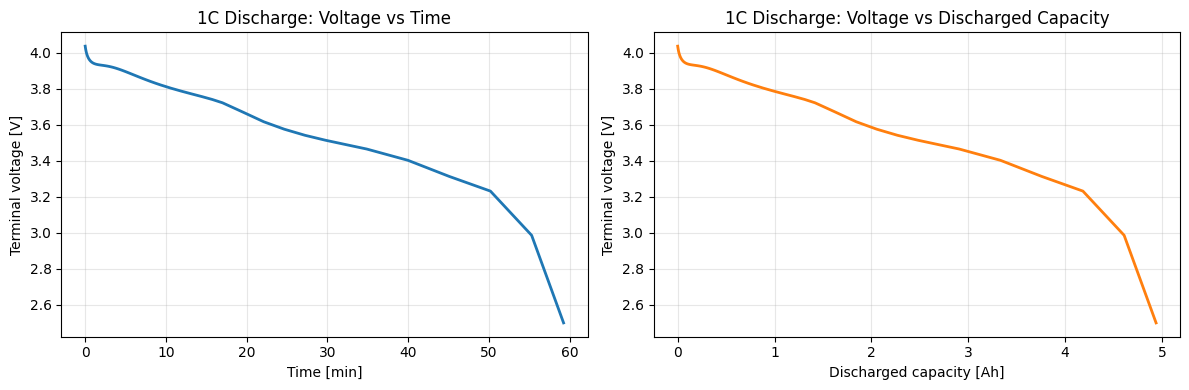

In [5]:
# 画 V vs t
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t / 60, V, linewidth=2, color='tab:blue')
ax1.set_xlabel("Time [min]")
ax1.set_ylabel("Terminal voltage [V]")
ax1.set_title("1C Discharge: Voltage vs Time")
ax1.grid(True, alpha=0.3)

ax2.plot(SOC, V, linewidth=2, color='tab:orange')
ax2.set_xlabel("Discharged capacity [Ah]")
ax2.set_ylabel("Terminal voltage [V]")
ax2.set_title("1C Discharge: Voltage vs Discharged Capacity")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()